In [1]:
import pandas as pd
import numpy as np
import json
import os
import sys
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
import sys
sys.path.append("../src")

In [3]:
%load_ext autoreload
%autoreload 2
from data_preprocessing import validate_dataframe, clean_data, encode_categoricals, preprocessor, check_data_quality

In [56]:
df_raw = pd.read_csv('../data/raw/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

In [57]:
print(df_raw['stress_level'].value_counts())

stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64


Splitting the data into 3 parts: Part 1 is 3500 rows for the initial model. Part 2 and 3 will be 2000 rows each and will be used for drift.

In [37]:
low_lev_index = df_raw[df_raw['stress_level'] == 'Low'].sample(1200).index
med_lev_index = df_raw[df_raw['stress_level'] == 'Medium'].sample(1200).index
high_lev_index = df_raw[df_raw['stress_level'] == 'High'].sample(1200).index

In [38]:
total_index = low_lev_index.append(med_lev_index).append(high_lev_index)
df_model = df_raw.iloc[total_index]
print(len(df_model))
print(df_model['stress_level'].value_counts())

3600
stress_level
Low       1200
Medium    1200
High      1200
Name: count, dtype: int64


In [50]:
df_model.reset_index(drop=True, inplace=True)
df_model.to_csv("../data/raw/Smartphone_Usage_And_Addiction_Analysis_3600_Rows.csv", index=False)

In [51]:
df_leftover = df_raw[~df_raw.index.isin(total_index)]
print(len(df_leftover))
print(df_leftover['stress_level'].value_counts())

3900
stress_level
High      1360
Low       1303
Medium    1237
Name: count, dtype: int64


In [43]:
low_left_index = df_leftover[df_leftover['stress_level'] == 'Low'].sample(700).index
med_left_index = df_leftover[df_leftover['stress_level'] == 'Medium'].sample(700).index
high_left_index = df_leftover[df_leftover['stress_level'] == 'High'].sample(600).index

In [44]:
left_index = low_left_index.append(med_left_index).append(high_left_index)
df_drift_1 = df_raw.iloc[left_index]
print(len(df_drift_1))
print(df_drift_1['stress_level'].value_counts())

2000
stress_level
Low       700
Medium    700
High      600
Name: count, dtype: int64


In [52]:
df_drift_1.reset_index(drop=True, inplace=True)
df_drift_1.to_csv("../data/raw/Smartphone_Usage_And_Addiction_Analysis_2000_Rows.csv", index=False)

In [47]:
df_drift_2 = df_leftover[~df_leftover.index.isin(left_index)]
print(len(df_drift_2))
print(df_drift_2['stress_level'].value_counts())

1900
stress_level
High      760
Low       603
Medium    537
Name: count, dtype: int64


In [53]:
df_drift_2.reset_index(drop=True, inplace=True)
df_drift_2.to_csv("../data/raw/Smartphone_Usage_And_Addiction_Analysis_1900_Rows.csv", index=False)

Clear Memory

In [4]:
# del df_model
# del df_leftover
# del df_drift_1
# del df_drift_2
# del low_left_index
# del med_left_index
# del high_left_index
# del low_lev_index
# del med_lev_index
# del high_lev_index
df_raw = pd.read_csv('../data/raw/Smartphone_Usage_And_Addiction_Analysis_3600_Rows.csv')
print(len(df_raw))
print(df_raw['stress_level'].value_counts())

3600
stress_level
Low       1200
Medium    1200
High      1200
Name: count, dtype: int64


In [5]:
focus_columns = ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                'app_opens_per_day', 'weekend_screen_time', 'academic_work_impact']
label_column = 'stress_level'

In [6]:
print("Validating Dataframe: ", validate_dataframe(df_raw, focus_columns, label_column))

Validating Dataframe:  True


In [7]:
df_features = df_raw[focus_columns]
print(len(df_raw))
print(df_features.sample(5))
df_features.info()

3600
      age gender  daily_screen_time_hours  social_media_hours  gaming_hours  \
827    31   Male                     9.83                3.13          0.38   
3492   21   Male                    10.31                4.19          1.79   
2312   33  Other                     6.79                3.27          2.51   
1010   33  Other                    10.78                0.71          1.98   
1976   18   Male                    10.70                1.92          1.28   

      work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
827               2.85         7.97                     59                107   
3492              1.31         4.64                    204                 42   
2312              1.21         5.60                     44                102   
1010              1.36         5.63                     91                117   
1976              1.70         4.87                    182                 21   

      weekend_screen_time academi

In [8]:
df_label = df_raw[label_column]
df_label.info()
print(df_label.value_counts())

<class 'pandas.core.series.Series'>
RangeIndex: 3600 entries, 0 to 3599
Series name: stress_level
Non-Null Count  Dtype 
--------------  ----- 
3600 non-null   object
dtypes: object(1)
memory usage: 28.3+ KB
stress_level
Low       1200
Medium    1200
High      1200
Name: count, dtype: int64


Since the dataset is clean we need to introduce some missing data

In [9]:
def sample_missing(df, column, frac=0.1, ):
    """
    Simulates missing Data by selecting random frac amount of rows and adding missing values to a column
    """
    out = df.copy()
    if column not in df.columns:
        print("Column Name Not Exist!!")
        return
    random_indices = out.sample(frac=frac).index
    out.loc[random_indices, column] = np.nan
    return out

In [10]:
rng = np.random.default_rng(seed=42)
df_missing = df_features.copy()
for col in focus_columns:
    df_missing = sample_missing(df_missing, col, round(rng.uniform(0.05, 0.15), 2))
df_missing.info()
print(df_missing.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3132 non-null   float64
 1   gender                   3276 non-null   object 
 2   daily_screen_time_hours  3096 non-null   float64
 3   social_media_hours       3168 non-null   float64
 4   gaming_hours             3384 non-null   float64
 5   work_study_hours         3060 non-null   float64
 6   sleep_hours              3132 non-null   float64
 7   notifications_per_day    3132 non-null   float64
 8   app_opens_per_day        3384 non-null   float64
 9   weekend_screen_time      3240 non-null   float64
 10  academic_work_impact     3276 non-null   object 
dtypes: float64(9), object(2)
memory usage: 309.5+ KB
       age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  \
3027   NaN    Male                     8.47             

In [11]:
corr = df_missing[focus_columns[2:-1]].corr()
print(corr)

                         daily_screen_time_hours  social_media_hours  \
daily_screen_time_hours                 1.000000           -0.015468   
social_media_hours                     -0.015468            1.000000   
gaming_hours                           -0.002043           -0.026198   
work_study_hours                        0.013779            0.021706   
sleep_hours                             0.027799            0.013591   
notifications_per_day                   0.011988           -0.018030   
app_opens_per_day                       0.021963           -0.009561   
weekend_screen_time                     0.963540            0.001898   

                         gaming_hours  work_study_hours  sleep_hours  \
daily_screen_time_hours     -0.002043          0.013779     0.027799   
social_media_hours          -0.026198          0.021706     0.013591   
gaming_hours                 1.000000         -0.003699    -0.010295   
work_study_hours            -0.003699          1.000000    -0.0

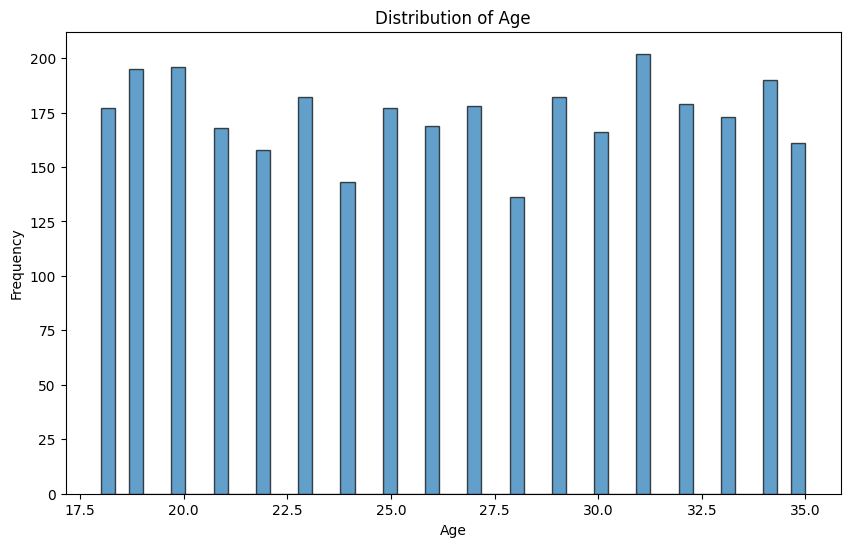

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_missing['age'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

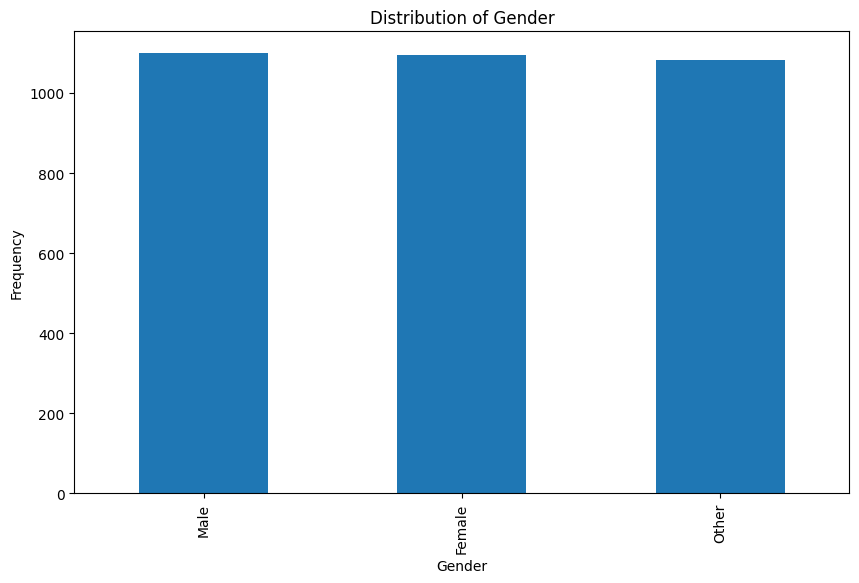

In [67]:
plt.figure(figsize=(10, 6))
df_missing['gender'].value_counts().plot(kind='bar')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

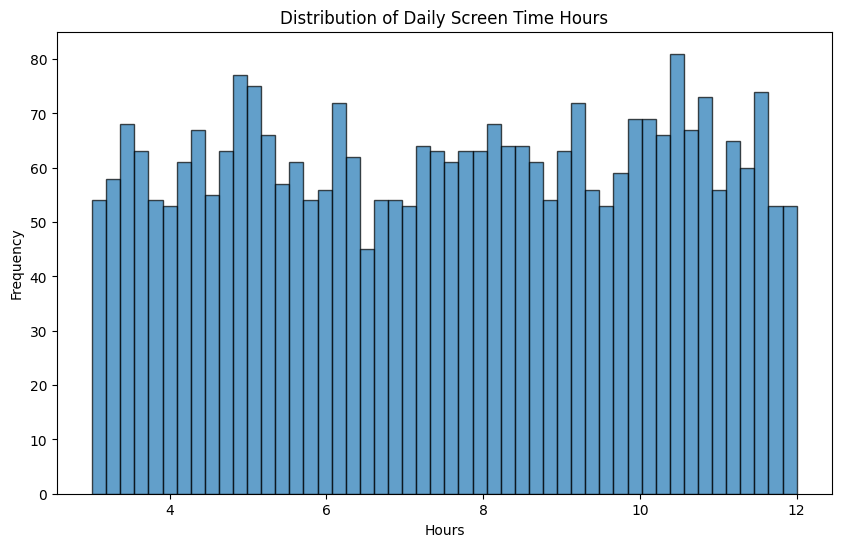

In [68]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['daily_screen_time_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Screen Time Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

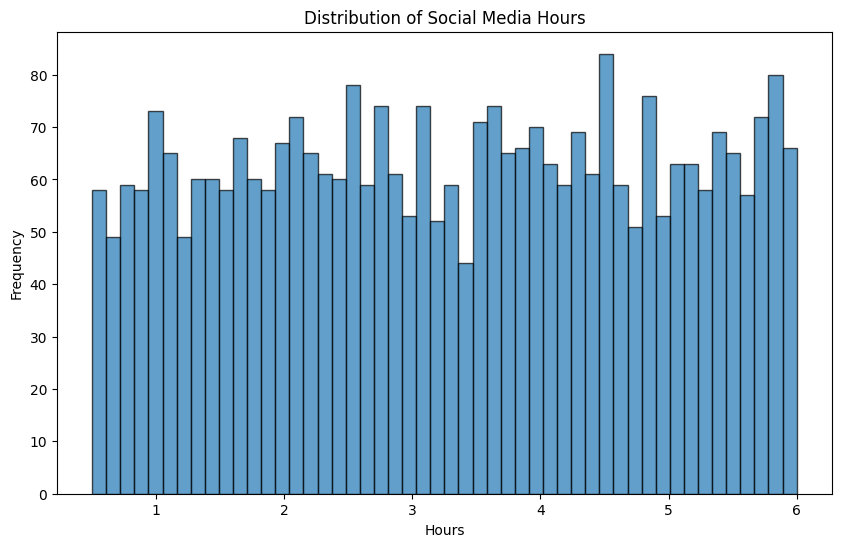

In [69]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['social_media_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Social Media Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

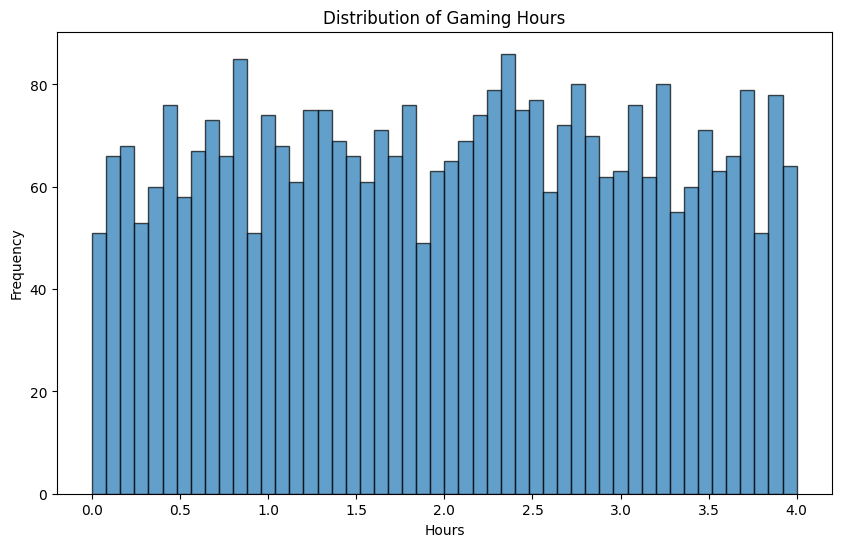

In [70]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['gaming_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Gaming Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

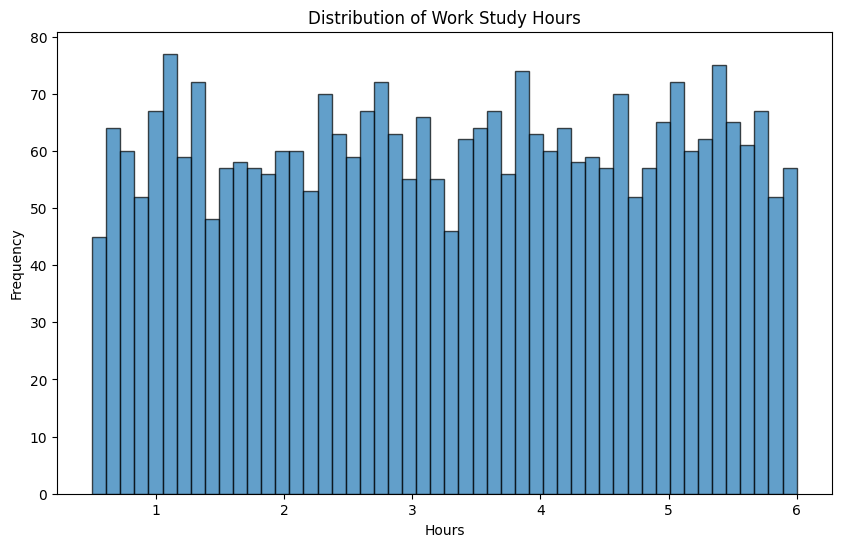

In [71]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['work_study_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Work Study Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

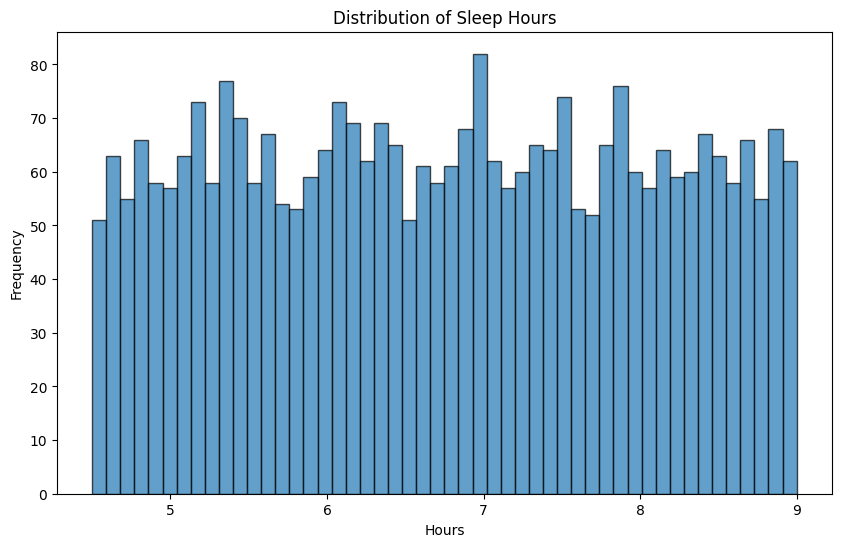

In [72]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['sleep_hours'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Sleep Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

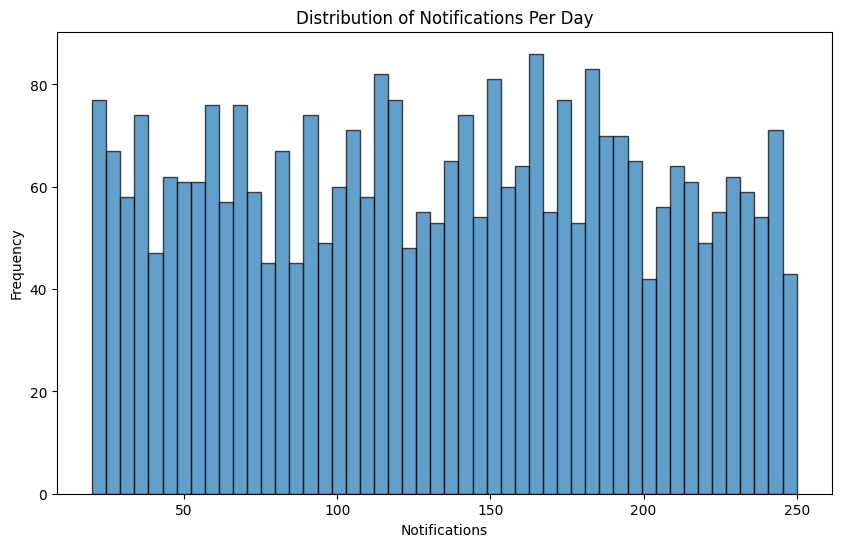

In [73]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['notifications_per_day'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Notifications Per Day')
plt.xlabel('Notifications')
plt.ylabel('Frequency')
plt.show()

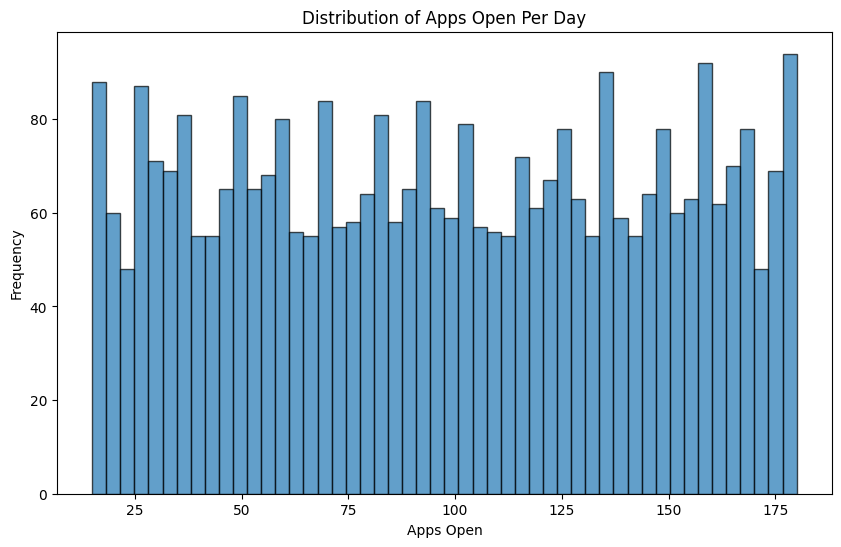

In [74]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['app_opens_per_day'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Apps Open Per Day')
plt.xlabel('Apps Open')
plt.ylabel('Frequency')
plt.show()

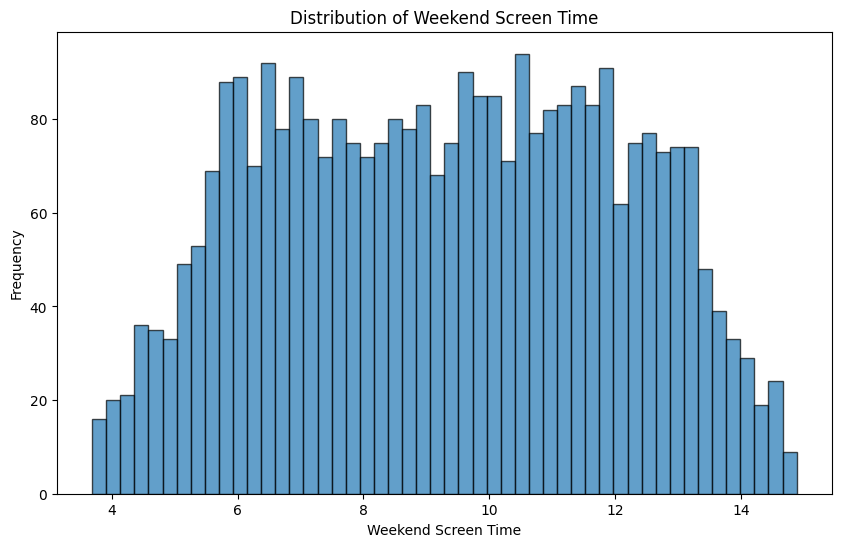

In [75]:
plt.figure(figsize=(10, 6))
plt.hist(df_missing['weekend_screen_time'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Weekend Screen Time')
plt.xlabel('Weekend Screen Time')
plt.ylabel('Frequency')
plt.show()

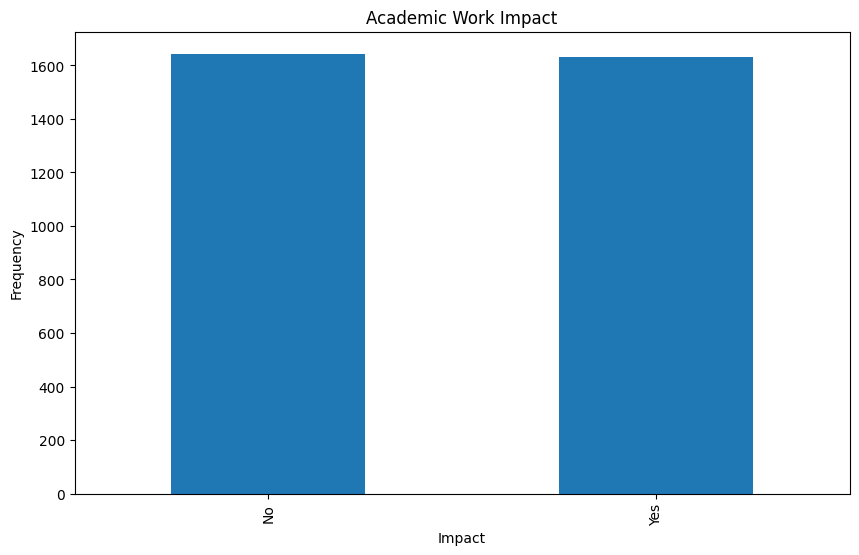

In [76]:
plt.figure(figsize=(10, 6))
df_missing['academic_work_impact'].value_counts().plot(kind='bar')
plt.title('Academic Work Impact')
plt.xlabel('Impact')
plt.ylabel('Frequency')
plt.show()

Age we are going to replace missing data with the median. Gender we are going to add a new category as unknown for the missing data. Acedemic Work Impact we are going to give it a new category unknown for missing data. Since there is a very strong correlation between daily_screen_time_hours and weekend_screen_time we can use the two to fill in the missing data. Normally I would want to do a KNN for all the rest of these missing data fields but for simplicity we will fill in the rest with the median.

In [77]:
def fill_median(df, col_name):
    if not col_name:
        print("Missing Column Name!!!!")
        return 

    med = df[col_name].median()
    df[col_name].fillna(med, inplace=True)
    print("Fill Complete")

In [78]:
def fill_unknown(df, col_name):
    if not col_name:
        print("Missing Column Name!!!!")
        return 

    df[col_name].fillna("UnKnown", inplace=True)
    print("Fill Complete")

In [12]:
df_missing['age'].median()
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3132 non-null   float64
 1   gender                   3276 non-null   object 
 2   daily_screen_time_hours  3096 non-null   float64
 3   social_media_hours       3168 non-null   float64
 4   gaming_hours             3384 non-null   float64
 5   work_study_hours         3060 non-null   float64
 6   sleep_hours              3132 non-null   float64
 7   notifications_per_day    3132 non-null   float64
 8   app_opens_per_day        3384 non-null   float64
 9   weekend_screen_time      3240 non-null   float64
 10  academic_work_impact     3276 non-null   object 
dtypes: float64(9), object(2)
memory usage: 309.5+ KB


In [13]:
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                'app_opens_per_day', 'weekend_screen_time']
cat_cols = ['gender', 'academic_work_impact']
df_clean = clean_data(df_missing, num_cols, cat_cols)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3600 non-null   int64  
 1   gender                   3600 non-null   object 
 2   daily_screen_time_hours  3600 non-null   float64
 3   social_media_hours       3600 non-null   float64
 4   gaming_hours             3600 non-null   float64
 5   work_study_hours         3600 non-null   float64
 6   sleep_hours              3600 non-null   float64
 7   notifications_per_day    3600 non-null   int64  
 8   app_opens_per_day        3600 non-null   int64  
 9   weekend_screen_time      3600 non-null   float64
 10  academic_work_impact     3600 non-null   object 
dtypes: float64(6), int64(3), object(2)
memory usage: 309.5+ KB


In [14]:
df_complete = encode_categoricals(df_clean, cat_cols)
print(df_complete.sample(10))

      age  daily_screen_time_hours  social_media_hours  gaming_hours  \
1664   31                   11.640                3.32          0.36   
2716   33                    5.160                4.00          0.62   
3281   32                    7.695                3.32          3.90   
1807   35                   11.420                5.83          1.14   
528    24                    6.260                3.95          2.40   
1547   32                   10.470                3.70          2.04   
1770   34                    6.330                1.79          1.93   
3239   20                    8.600                3.32          2.04   
1199   26                    4.660                2.69          1.98   
978    19                    7.760                4.00          1.45   

      work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
1664              5.97         5.32                    118                105   
2716              6.00         6.76          

In [15]:
print("Data Preprocessing Report: ", check_data_quality(df_complete, num_cols))

Data Preprocessing Report:  {'total_rows': 3600, 'total_nulls': 0, 'null_percentage': 0.0, 'duplicate_rows': 0, 'age_min': 18.0, 'age_max': 35.0, 'daily_screen_time_hours_min': 3.01, 'daily_screen_time_hours_max': 12.0, 'social_media_hours_min': 0.5, 'social_media_hours_max': 6.0, 'gaming_hours_min': 0.0, 'gaming_hours_max': 4.0, 'work_study_hours_min': 0.5, 'work_study_hours_max': 6.0, 'sleep_hours_min': 4.5, 'sleep_hours_max': 9.0, 'notifications_per_day_min': 20.0, 'notifications_per_day_max': 250.0, 'app_opens_per_day_min': 15.0, 'app_opens_per_day_max': 180.0, 'weekend_screen_time_min': 3.63, 'weekend_screen_time_max': 14.88}


Label Preprocessing: Convert Low, Med, High into 0, 1, 2

In [16]:
df_label = df_label.map({"Low": 0, "Medium": 1, "High": 2})
print(df_label.sample(10))

1062    0
1570    1
2215    1
2641    2
729     0
1817    1
1813    1
3506    2
1464    1
2565    2
Name: stress_level, dtype: int64


In [17]:
features_temp, features_test, target_temp, target_test = train_test_split(
    df_complete, df_label, test_size=0.2, random_state=42
)
features_train, features_valid, target_train, target_valid = train_test_split(
    features_temp, target_temp, test_size=0.25, random_state=12345
)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Feature Data Preprocessing: Normalize the values.

In [19]:
minmax_cols = ["age", "sleep_hours"]
standard_cols = ["daily_screen_time_hours", "social_media_hours", "gaming_hours",
                 "work_study_hours", "notifications_per_day", "app_opens_per_day",
                 "weekend_screen_time"]

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("minmax", MinMaxScaler(), minmax_cols),
#         ("standard", StandardScaler(), standard_cols)
#     ],
#     remainder="passthrough"
# )
preprocessor = preprocessor(minmax_cols, standard_cols)
features_train_scaled = preprocessor.fit_transform(features_train)
features_test_scaled = preprocessor.transform(features_test)

In [20]:
features_valid_scaled = preprocessor.transform(features_valid)

Read Model Config

In [21]:
import json
# with open("../configs/random_forest_v1.json") as f:
#     config = json.load(f)
with open("../configs/gradient_boosting_v1.json") as f:
    config = json.load(f)

In [22]:
if config["model"] == "RandomForest":
    model = RandomForestClassifier(
        n_estimators=config["params"]["n_estimators"], 
        max_depth=config["params"]["max_depth"],
        random_state=config["params"]["random_state"]
    )
elif config["model"] == "Logistic Regression":
    model = LogisticRegression(
        C=config["params"]["C"],
        max_iter=config["params"]["max_iter"],
        random_state=config["params"]["random_state"]
    )
elif config["model"] == "Gradient Boosting":
    model = HistGradientBoostingClassifier(
        learning_rate=config["params"]["learning_rate"],
        max_depth=config["params"]["max_depth"],
        random_state=config["params"]["random_state"]
    )

In [23]:
model.fit(features_train_scaled, target_train)
predicted_valid = model.predict(features_valid_scaled)

In [24]:
print(f"Accuracy:  {accuracy_score(target_valid, predicted_valid):.1%}")
print(f"Precision: {precision_score(target_valid, predicted_valid, average='macro'):.1%}")
print(f"Recall:    {recall_score(target_valid, predicted_valid, average='macro'):.1%}")
print(f"F1 Score:  {f1_score(target_valid, predicted_valid, average='macro'):.1%}")

Accuracy:  35.7%
Precision: 35.9%
Recall:    35.7%
F1 Score:  35.7%
